# COLAB 2: Processing multi-subject datasets with high-performance computing

## Course architecture

Data acquisition ➡️ Training an ML model ➡️ Visualizing results ➡️ Documenting research

## Instructions for the student
In this lab, you will train a machine learning (ML) model (convolutional neural network, CNN) on temporal EEG data recorded from multiple subjects and channels.

Your objective is to pass the explicit **"AI Prompt Challenges"** directly to an AI coding assistant, evaluate the structural properties of the returned functions, and paste them into the designated code boundaries.

## Module 0: Setting up an environment on FABRIC

**Student AI prompt challenge**

Copy and paste the code block from the cell below and the following text block into your AI assistant:

> "Give me commands I can use in the ubuntu terminal to (1) install anaconda, (2) create a conda environment, (3) activate that environment, (4) install numpy, pandas, matplotlib, pytorch (GPU-compatible)." 

## Module 1: Data acquisition

We will continue working with the [EEG Emotion Recognition dataset](https://www.kaggle.com/datasets/wajahat1064/emotion-recognition-using-eeg-and-computer-games?resource=download), acquiring data from all 28 subjects. The cells below download the full dataset from Kaggle.

In [6]:
import kagglehub
import os

# Download from kaggle
path = kagglehub.dataset_download("wajahat1064/emotion-recognition-using-eeg-and-computer-games")
print("Dataset downloaded to:", path)

path = os.path.join(path, 
                     "Dataset - Emotion Recognition data Based on EEG Signals and Computer Games", 
                     "Database for Emotion Recognition System Based on EEG Signals and Various Computer Games - GAMEEMO",
                     "GAMEEMO"
                    )

Dataset downloaded to: /home/ubuntu/.cache/kagglehub/datasets/wajahat1064/emotion-recognition-using-eeg-and-computer-games/versions/2


**Student AI prompt challenge**

The `subjects` variable below should hold subject identifiers from the dataset (S01-S28). Design a prompt and define this variable with the AI.

In [ ]:
#TODO: your code here


In [103]:
print(len(subjects))

28


The functions below read data from a single subjects and combine the resulting dataset into an array of size (subjects x game_types x channels x time).

In [105]:
import numpy as np
import pandas as pd

def read_subject(subject, path):
    assert len(os.listdir(path)) == 4
    
    subject_recordings = []
    for game_idx in range(4):
        # Read channel x time data
        csv_filename = f'{subject}G{game_idx + 1}AllChannels.csv'
        df = pd.read_csv(os.path.join(path, csv_filename))
        df.drop("Unnamed: 14", axis = 1, inplace = True)

        # Shape into a channels x time array
        subject_recordings.append(df.to_numpy().T)

    # Shape into game_types x channels x time
    subject_recordings = np.stack(subject_recordings)
        
    return subject_recordings

def read_subjects(subjects, path):
    all_recordings = []
    for subject in subjects:
        subject_path = os.path.join(path, f"({subject})", "Preprocessed EEG Data", ".csv format")
        data = read_subject(subject, subject_path)
        all_recordings.append(data)

    # Subjects x game_types x channels x time
    all_recordings = np.stack(all_recordings)
    return all_recordings

In [106]:
data = read_subjects(subjects, path)

FileNotFoundError: [Errno 2] No such file or directory: '/home/ubuntu/.cache/kagglehub/datasets/wajahat1064/emotion-recognition-using-eeg-and-computer-games/versions/2/Dataset - Emotion Recognition data Based on EEG Signals and Computer Games/Database for Emotion Recognition System Based on EEG Signals and Various Computer Games - GAMEEMO/GAMEEMO/(S26)/Preprocessed EEG Data/.csv format'

**Student AI prompt challenge**

As you can see, there is an error when reading data of one of the subjects. Design a prompt to list the contents of the subject's directory and compare the contents with antoher subject (e.g., subject S01). What is the problem?

In [ ]:
#TODO: your code here: list the contents of S26's directory and compare with S01


**Student AI prompt challenge**

Prompt AI to modify the list of subjects to exclude subject 26 (but still include subjects 1-25 and 27-28).

In [ ]:
#TODO: your code here


In [112]:
data = read_subjects(subjects, path)

# Subjects x game_types x channels x time
print(data.shape)

(27, 4, 14, 38252)


## Module 2: Training an ML model

We are going to train a convolutional neural network (CNN) to predict the game type from the temporal data across channels of all available subjects.

**Student AI prompt challenge**

Copy and paste the code block from the cell below and the following text block into your AI assistant:

> "I am working with a dataset of size subjects x conditions x channels x time, my actual shape is (27, 4, 14, 38252). The data are currently stored as a numpy array. Write pytorch code that trains a simple CNN on that data to predict the condition (i.e., multiclass classification over 4 classes). Treat each subject x condition as a separate sample and make the CNN layers 1d (i.e., we convolve across time). The first layer should take 14 channels as evident from my data shape. Also leave 3 subjects out for validation (i.e., train only on 24 subjects) and add some one-time testing step (compute accuracy across the 3 subjects). Track loss and training accuracy so that I can plot them / save them later."

In [ ]:
#TODO: your code here


(96, 14, 38252)
(12, 14, 38252)
Epoch   1 | Train Loss 1.8069 | Train Acc 0.240 | Val Loss 1.4065 | Val Acc 0.250
Epoch   2 | Train Loss 1.3897 | Train Acc 0.260 | Val Loss 1.3861 | Val Acc 0.167
Epoch   3 | Train Loss 1.3841 | Train Acc 0.271 | Val Loss 1.3873 | Val Acc 0.250
Epoch   4 | Train Loss 1.3812 | Train Acc 0.260 | Val Loss 1.3871 | Val Acc 0.167
Epoch   5 | Train Loss 1.3763 | Train Acc 0.302 | Val Loss 1.3844 | Val Acc 0.250
Epoch   6 | Train Loss 1.3641 | Train Acc 0.323 | Val Loss 1.3876 | Val Acc 0.333
Epoch   7 | Train Loss 1.3481 | Train Acc 0.344 | Val Loss 1.3795 | Val Acc 0.333
Epoch   8 | Train Loss 1.3583 | Train Acc 0.312 | Val Loss 1.4847 | Val Acc 0.333
Epoch   9 | Train Loss 1.3038 | Train Acc 0.292 | Val Loss 1.3765 | Val Acc 0.250
Epoch  10 | Train Loss 1.2600 | Train Acc 0.396 | Val Loss 1.3641 | Val Acc 0.333
Epoch  11 | Train Loss 1.2159 | Train Acc 0.406 | Val Loss 1.4343 | Val Acc 0.250
Epoch  12 | Train Loss 1.1010 | Train Acc 0.448 | Val Loss 1.3635 

## Module 3: Visualizing results

**Student AI prompt challenge**

Design a prompt to plot the saved train and validation losses and accuracies.

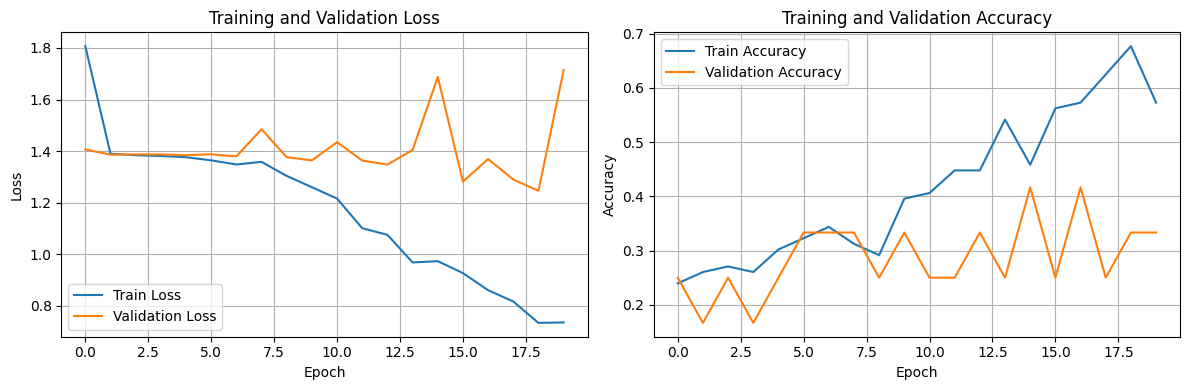

In [ ]:
#TODO: your code here


## Module 4: Documenting research

**Student AI prompt challenge**
Design a prompt to save the resulting  train and validation losses and accuracies in a `.csv` file.

In [ ]:
#TODO: your code here


## Module 5: Additional prompt challenges

1. **Beat the Baseline:** Use AI to modify the CNN architecture (number of layers, kernel sizes, channels, pooling) and improve validation accuracy over the provided baseline.
2. **Try Different Optimizers:** Replace Adam with SGD, RMSprop, or AdamW. Compare convergence speed and final accuracy.
3. **Learning Rate Tuning:** Use AI to implement a learning rate scheduler (e.g., StepLR, CosineAnnealingLR, ReduceLROnPlateau) and determine whether it improves performance.
4. **Normalization Challenge:** Normalize the EEG channels (e.g., z-score using only the training subjects). Compare results with the unnormalized data.
5. **Confusion Matrix:** Compute and visualize the confusion matrix for the held-out subjects. Which conditions are most frequently confused?